In [1]:
from utils.common import prepare_dataset, data_split, train_catboost, calculate_metrics, get_most_important_features, make_lags_dataset

df = prepare_dataset('../trading_df.csv',
                    exclude_cols=['cred_limit', 'fin_cond_index', 'tax_regime', 'reg_date', 'Unnamed: 0'], 
                    year_col='year',
                    id_col='vat_num',
                    dflt_col='dflt_year',
                    drop_fin_zeroes=True,
                    drop_ones_after_ones=True)

df = make_lags_dataset(df, [1])

/home/jovyan/дефолт/inference/utils/common.py:40: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df_path)


Длина датасета: 602624
Распределение таргета:
dflt_year
0    600709
1      1915
Name: count, dtype: int64
Длина датасета после добавления лаг фичей и отчистки строк с отсутствующими лаг-значениями: 540724
Распределение таргета:
target
0    538829
1      1895
Name: count, dtype: int64


In [2]:
X_train, y_train, X_val, y_val, X_test, y_test = data_split(df, train_year_max=2022, val_year=2023, test_year=2024, target_col="target")

In [3]:
model = train_catboost(X_train, 
                       y_train, 
                       X_val, 
                       y_val,
                       iterations_num=10_000,
                       eval_metric="AUC",
                       learning_rate=0.01,
                       random_seed=42,
                       verbose=200,
                       early_stopping_rounds=200,
                       class_weights=None)

0:	test: 0.5694754	best: 0.5694754 (0)	total: 112ms	remaining: 18m 43s
200:	test: 0.9048098	best: 0.9048098 (200)	total: 12.8s	remaining: 10m 23s
400:	test: 0.9149365	best: 0.9149365 (400)	total: 24.1s	remaining: 9m 37s
600:	test: 0.9175811	best: 0.9175886 (599)	total: 34.6s	remaining: 9m 1s
800:	test: 0.9191777	best: 0.9191797 (783)	total: 44.6s	remaining: 8m 32s
1000:	test: 0.9208981	best: 0.9208981 (1000)	total: 54.8s	remaining: 8m 12s
1200:	test: 0.9221536	best: 0.9221536 (1200)	total: 1m 4s	remaining: 7m 55s
1400:	test: 0.9234871	best: 0.9235182 (1398)	total: 1m 14s	remaining: 7m 39s
1600:	test: 0.9243368	best: 0.9243768 (1588)	total: 1m 24s	remaining: 7m 25s
1800:	test: 0.9251291	best: 0.9251291 (1800)	total: 1m 34s	remaining: 7m 11s
2000:	test: 0.9260110	best: 0.9260110 (2000)	total: 1m 44s	remaining: 6m 59s
2200:	test: 0.9267596	best: 0.9267596 (2200)	total: 1m 54s	remaining: 6m 47s
2400:	test: 0.9272796	best: 0.9272897 (2389)	total: 2m 4s	remaining: 6m 35s
2600:	test: 0.927854

In [4]:
metrics = calculate_metrics(model, X_test, y_test)

AUC: 0.9088129706798665
Brier: 0.01267364068444834
LogLoss: 0.06246223499693358



Top 20 features by importance:
                             feature  importance
0                1250_cash_and_equiv    7.142545
1                                roa    6.450290
2                     2400_net_pofit    3.447159
3          debt_to_total_liabilities    2.647612
4                           2300_ebt    2.569641
5                     1210_inventory    2.219488
6                  2410_inc_tax_lag1    1.788406
7                       2410_inc_tax    1.767098
8             fa_turnover_ratio_lag1    1.548645
9                 absolute_liquidity    1.534252
10        4221_non_curr_assets_purch    1.493029
11                 net_profit_margin    1.405615
12           2120_cost_of_sales_lag1    1.307727
13    debt_to_total_liabilities_lag1    1.279392
14                  days_sales_outst    1.223798
15               1210_inventory_lag1    1.192418
16                   roa_ru_tax_lag1    1.115693
17                 payables_turnover    1.084625
18             total_assets_turnover 

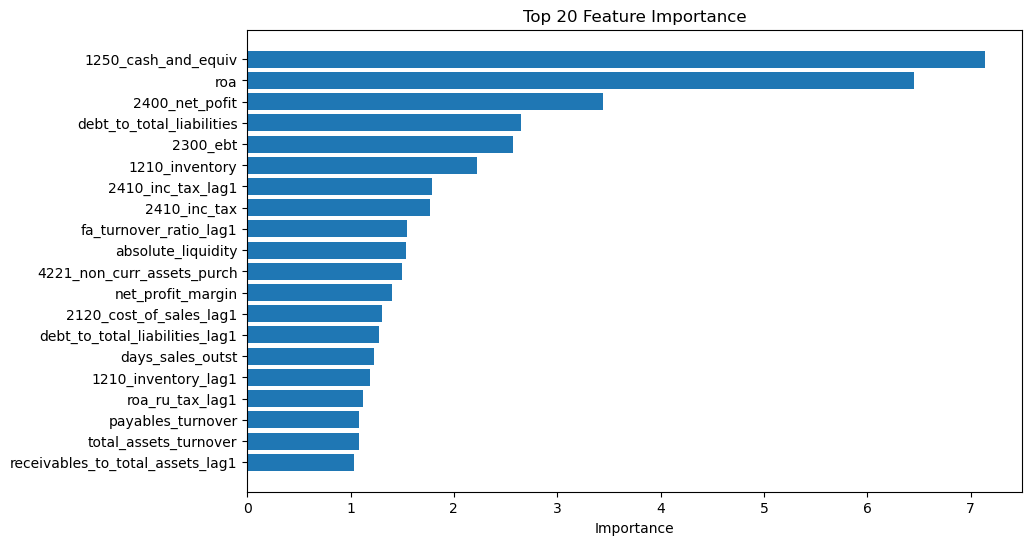

In [5]:
fi_df = get_most_important_features(model, show=20)

In [6]:
from utils.common import calibrate_model

calibrated_model = calibrate_model(model, X_val, y_val)

In [7]:
calibrated_metrics = calculate_metrics(calibrated_model, X_test, y_test)

AUC: 0.9080697435288716
Brier: 0.012066696819674162
LogLoss: 0.05455796208915564


In [8]:
from utils.exp_handler import save_exp

save_exp(X_train, 
         y_train, 
         X_val, 
         y_val, 
         X_test, 
         y_test,
         model,
         metrics=calibrated_metrics,
         fi_df=fi_df,
         calibrated_model=calibrated_model,
         name='big_df_lag1',
         save_data=False)

'exp/big_df_lag1'

Predicted calibrated probability: 0.0046641791044776115


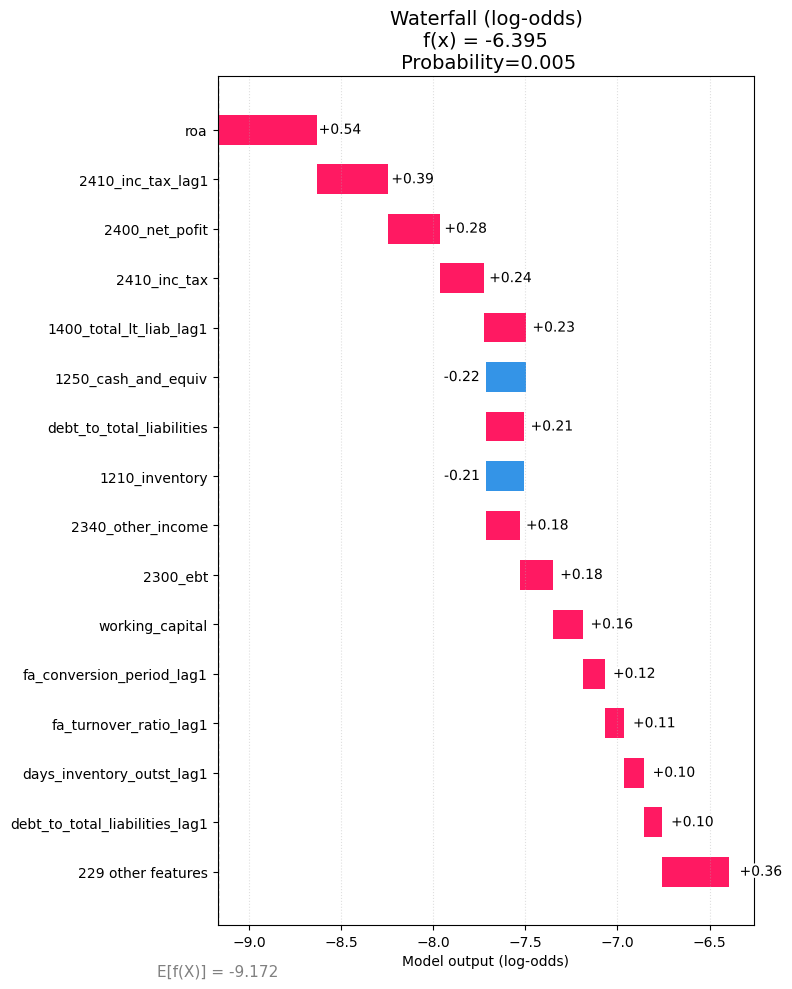

In [9]:
from utils.waterfall_graph import show_waterfall_graph


x0 = X_test.iloc[1]
show_waterfall_graph(model, calibrated_model, x0, top_k=15)
